In [1]:
!uv pip install seaborn matplotlib

Using Python 3.12.7 environment at: /Users/manaskolaskar/Developer/Projects/spotify-india-intelligence/.venv
Checked 2 packages in 47ms


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set visualization style to look premium (dark theme to match our dashboard)
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

# Load Cleaned Data
DATA_PATH = Path("../data/processed/indian_songs_cleaned.parquet")
df = pd.read_parquet(DATA_PATH)

print(f"✅ Data loaded successfully: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

✅ Data loaded successfully: 34,999 rows x 19 columns


,song_name,singer,singer_id,language,released_date,danceability,acousticness,energy,liveness,loudness,speechiness,tempo,mode,key,valence,time_signature,popularity,stream,duration_ms
0,Naguva Nayana,S. Janaki|S. P. Balasubrahmanyam,/artist/s-janaki|/artist/s-p-balasubrahamanyam,Kannada,09-10-2020,0.53,0.110,0.444,0.800,-7.552,0.0930,133.899,0.0,8.0,0.0400,4.0,74.0,5316814.0,252000
1,Ellelli Nodali,S. Janaki|Dr. Rajkumar,/artist/s-janaki|/artist/dr-rajkumar-1,Kannada,07-09-2018,0.66,0.361,0.695,0.511,-13.317,0.0615,130.000,0.0,0.0,0.0300,4.0,62.0,4573499.0,271000
2,Chinnada Mallige Hoove,S. Janaki|Dr. Rajkumar,/artist/s-janaki|/artist/dr-rajkumar-1,Kannada,09-08-2014,0.58,0.420,0.472,0.600,-6.833,0.0600,168.010,0.0,4.0,0.0985,4.0,25.0,4709951.0,275000
3,Premalokadinda,K J Yesudas|S. Janaki,/artist/k-j-yesudas|/artist/s-janaki,Kannada,04-11-2018,0.14,0.037,0.258,0.237,-6.416,0.0595,123.004,0.0,1.0,0.0210,4.0,58.0,1388726.0,275000
4,Preethiyalli Iro Sukha,S. P. Balasubrahmanyam|Manjula Gururaj,/artist/s-p-balasubrahamanyam|/artist/manjula-...,Kannada,03-05-2012,0.80,0.560,0.584,0.800,-3.596,0.0010,113.973,1.0,1.0,0.0766,4.0,68.0,1655326.0,281000


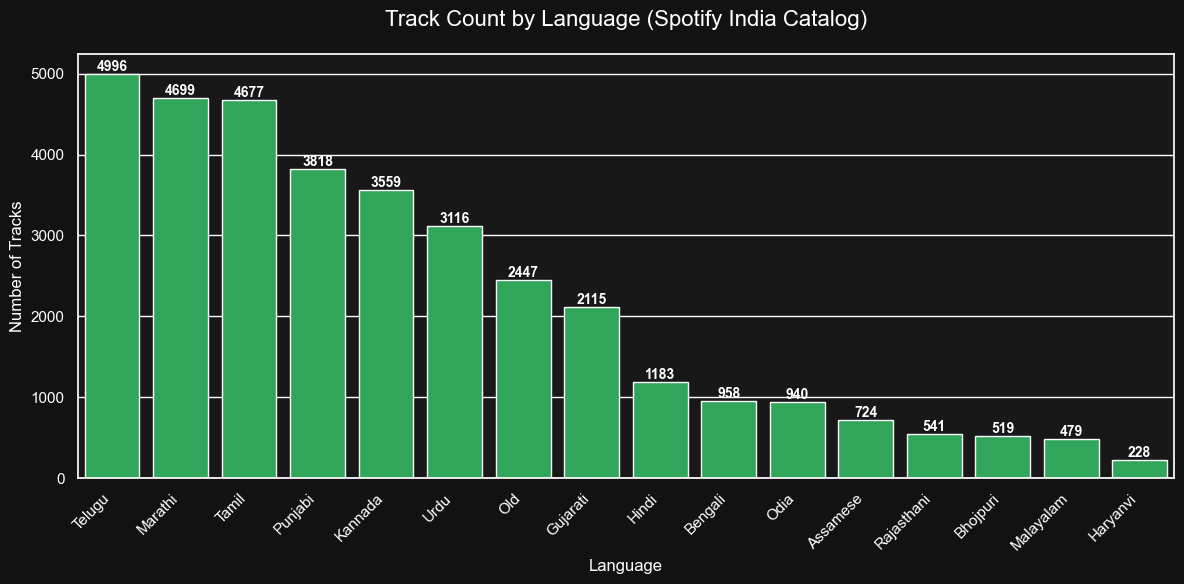

In [3]:
# Business Question 1: Which languages dominate the catalog?

# Count tracks per language
lang_counts = df['language'].value_counts().reset_index()
lang_counts.columns = ['language', 'track_count']

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=lang_counts, x='language', y='track_count', color='#1DB954') # Spotify Green

# Add labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')

plt.title('Track Count by Language (Spotify India Catalog)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Number of Tracks', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/bz/8kbj9jln5hx_yqm6slqjr2sh0000gn/T/ipykernel_2105/486401879.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lang_pop, x='language', y='avg_popularity', palette="viridis")


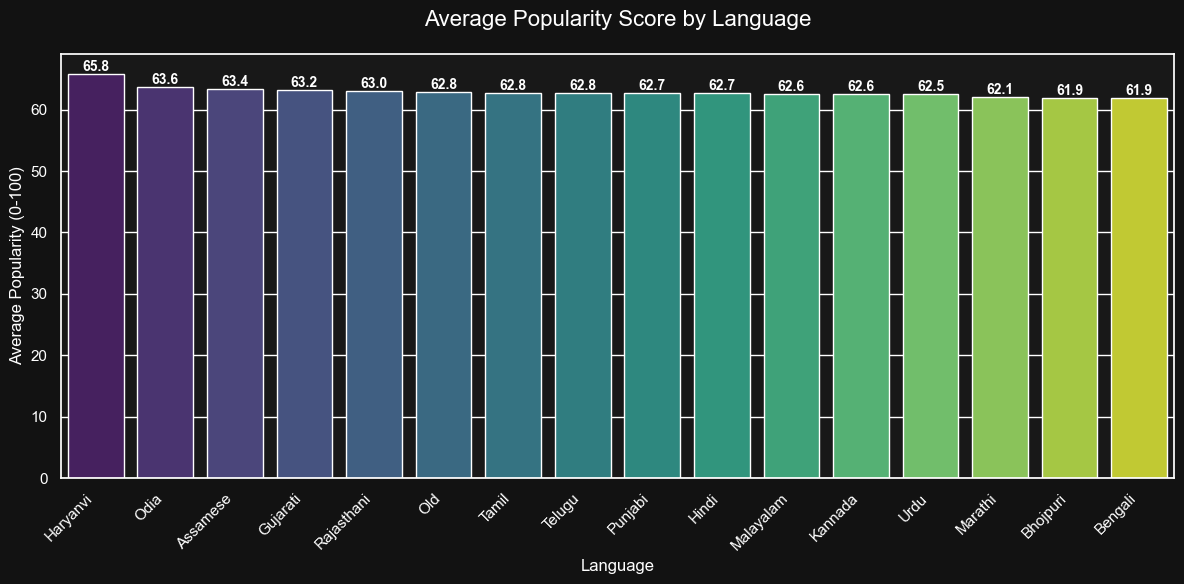

In [4]:
# Business Question 2: Which languages have the highest average popularity?

# Calculate mean popularity per language, sorted descending
lang_pop = df.groupby('language')['popularity'].mean().sort_values(ascending=False).reset_index()
lang_pop.columns = ['language', 'avg_popularity']

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=lang_pop, x='language', y='avg_popularity', palette="viridis")

# Add the exact numbers on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')

plt.title('Average Popularity Score by Language', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Average Popularity (0-100)', fontsize=12)
plt.tight_layout()
plt.show()

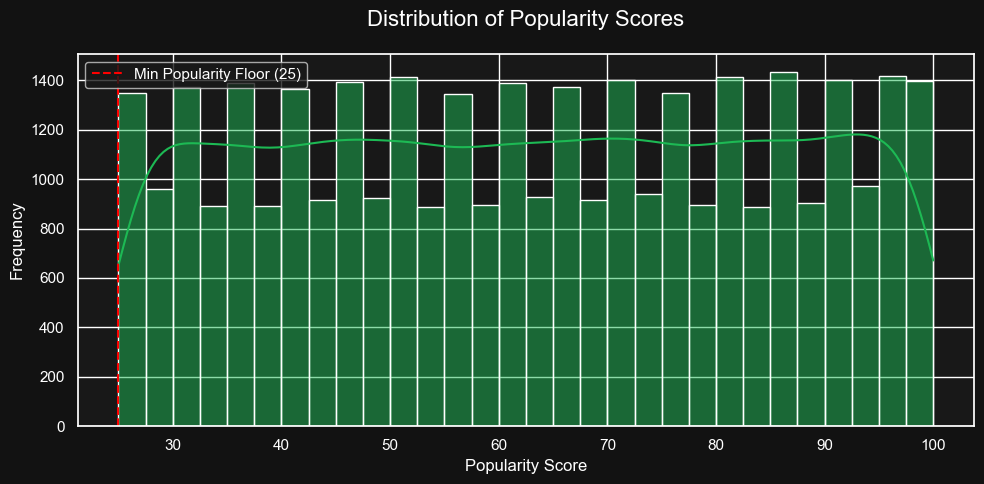

Popularity Statistics:
count    34999.000000
mean        62.677848
std         21.976121
min         25.000000
25%         44.000000
50%         63.000000
75%         82.000000
max        100.000000
Name: popularity, dtype: float64


In [5]:
# Business Question 3: How is popularity distributed? (Validating our 25-point floor bias)

plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=30, kde=True, color='#1DB954')

plt.title('Distribution of Popularity Scores', fontsize=16, pad=20)
plt.xlabel('Popularity Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=25, color='red', linestyle='--', label='Min Popularity Floor (25)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Popularity Statistics:\n{df['popularity'].describe()}")


#### Audio Feature Intelligence
Objective: Understand how audio features correlate with popularity and how the "Audio DNA" differs across major Indian languages.



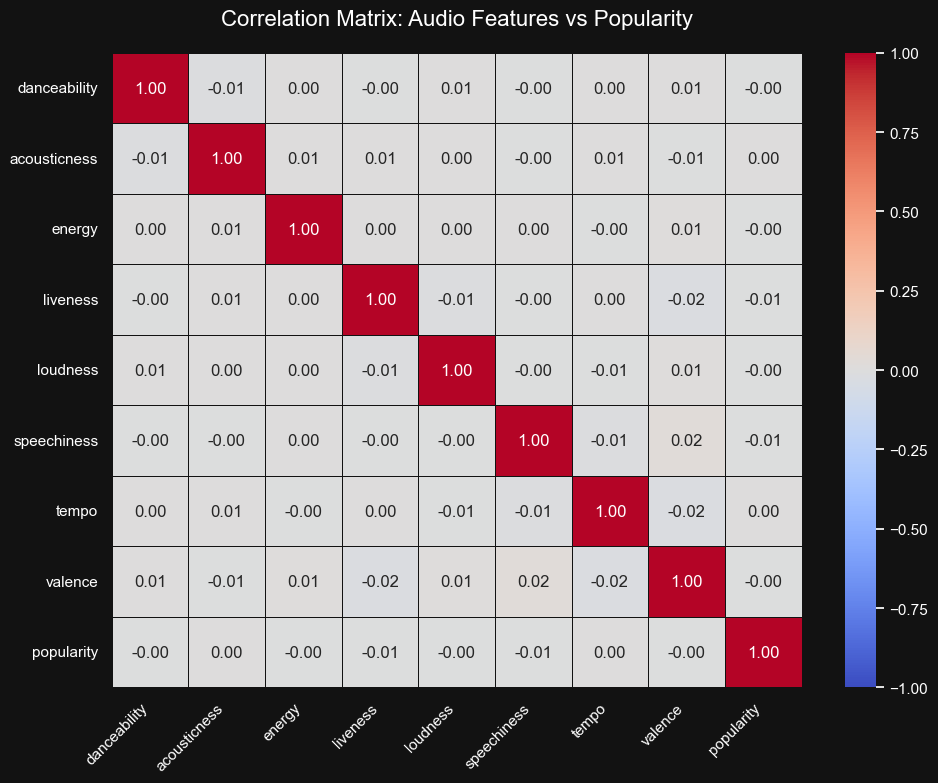

📊 Correlation with Popularity (Sorted):
tempo           0.002904
acousticness    0.002816
danceability   -0.000143
valence        -0.003244
energy         -0.003925
loudness       -0.004976
liveness       -0.005386
speechiness    -0.006128
Name: popularity, dtype: float64


In [6]:
# How do audio features correlate with each other and popularity?

# Select only the numeric audio features + popularity
audio_cols = ['danceability', 'acousticness', 'energy', 'liveness', 
              'loudness', 'speechiness', 'tempo', 'valence', 'popularity']

corr_matrix = df[audio_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, linecolor='#121212', vmin=-1, vmax=1)

plt.title('Correlation Matrix: Audio Features vs Popularity', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# What is the correlation of each feature with popularity specifically?
print("📊 Correlation with Popularity (Sorted):")
print(corr_matrix['popularity'].sort_values(ascending=False).drop('popularity'))

/var/folders/bz/8kbj9jln5hx_yqm6slqjr2sh0000gn/T/ipykernel_2105/1512589849.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_langs, x='language', y='energy', ax=axes[0], palette='viridis')
/var/folders/bz/8kbj9jln5hx_yqm6slqjr2sh0000gn/T/ipykernel_2105/1512589849.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_langs, x='language', y='danceability', ax=axes[1], palette='magma')


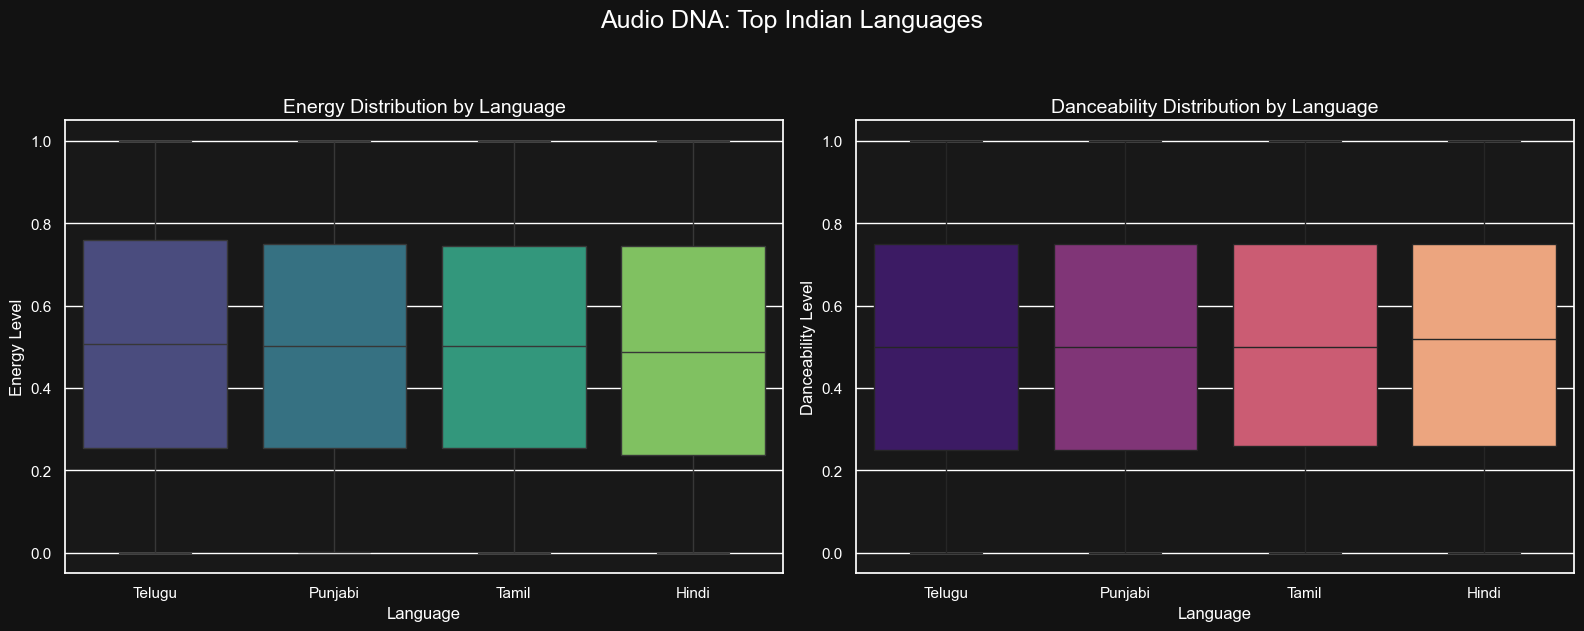

In [7]:
# Do different languages have different audio profiles?
# Let's compare Energy and Danceability across the top 4 languages

top_languages = ['Telugu', 'Hindi', 'Tamil', 'Punjabi']
df_top_langs = df[df['language'].isin(top_languages)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Energy by Language
sns.boxplot(data=df_top_langs, x='language', y='energy', ax=axes[0], palette='viridis')
axes[0].set_title('Energy Distribution by Language', fontsize=14)
axes[0].set_xlabel('Language', fontsize=12)
axes[0].set_ylabel('Energy Level', fontsize=12)

# Plot 2: Danceability by Language
sns.boxplot(data=df_top_langs, x='language', y='danceability', ax=axes[1], palette='magma')
axes[1].set_title('Danceability Distribution by Language', fontsize=14)
axes[1].set_xlabel('Language', fontsize=12)
axes[1].set_ylabel('Danceability Level', fontsize=12)

plt.suptitle('Audio DNA: Top Indian Languages', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [8]:
# Aggregate artist metrics
artist_df = df.groupby('singer').agg(
    track_count=('song_name', 'count'),
    avg_popularity=('popularity', 'mean'),
    total_streams=('stream', 'sum')
).reset_index()

# Filter out one-hit wonders (only artists with 5+ tracks)
established_artists = artist_df[artist_df['track_count'] >= 5].copy()

# Sort by track count for the first plot
top_by_volume = established_artists.sort_values('track_count', ascending=False).head(10)

# Sort by average popularity for the second plot
top_by_popularity = established_artists.sort_values('avg_popularity', ascending=False).head(10)

print(f"Total unique artist strings: {len(artist_df)}")
print(f"Established artists (5+ tracks): {len(established_artists)}")

Total unique artist strings: 5859
Established artists (5+ tracks): 1029


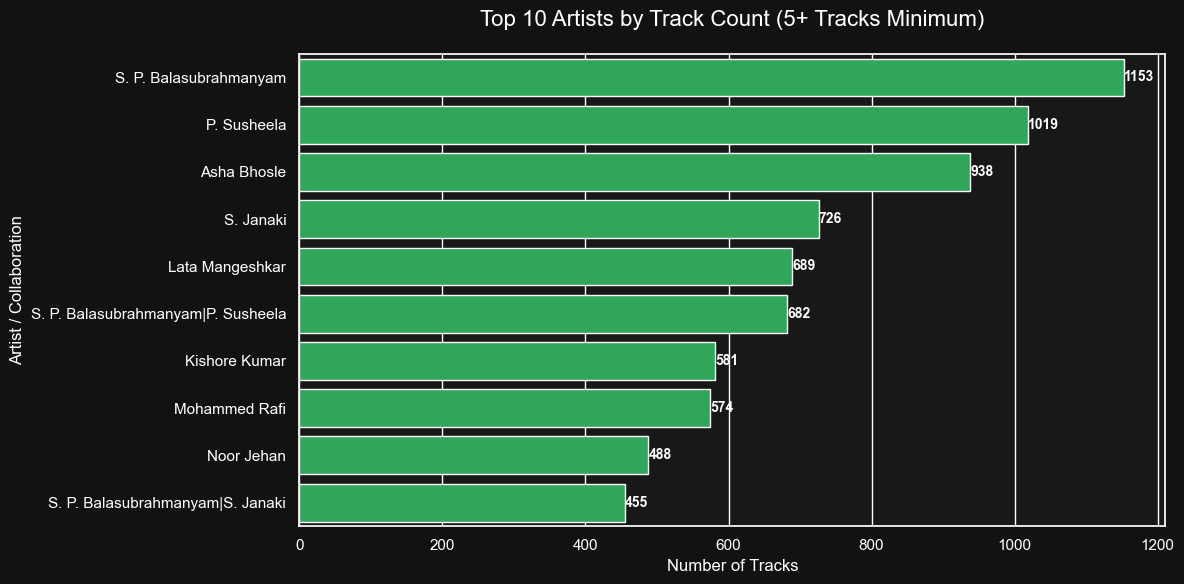

In [9]:
# Plot 1: Top 10 Artists by Track Count
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_by_volume, y='singer', x='track_count', color='#1DB954')

# Add labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, color='white', fontweight='bold')

plt.title('Top 10 Artists by Track Count (5+ Tracks Minimum)', fontsize=16, pad=20)
plt.xlabel('Number of Tracks', fontsize=12)
plt.ylabel('Artist / Collaboration', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/bz/8kbj9jln5hx_yqm6slqjr2sh0000gn/T/ipykernel_2105/3753920670.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_by_popularity, y='singer', x='avg_popularity', palette='magma')


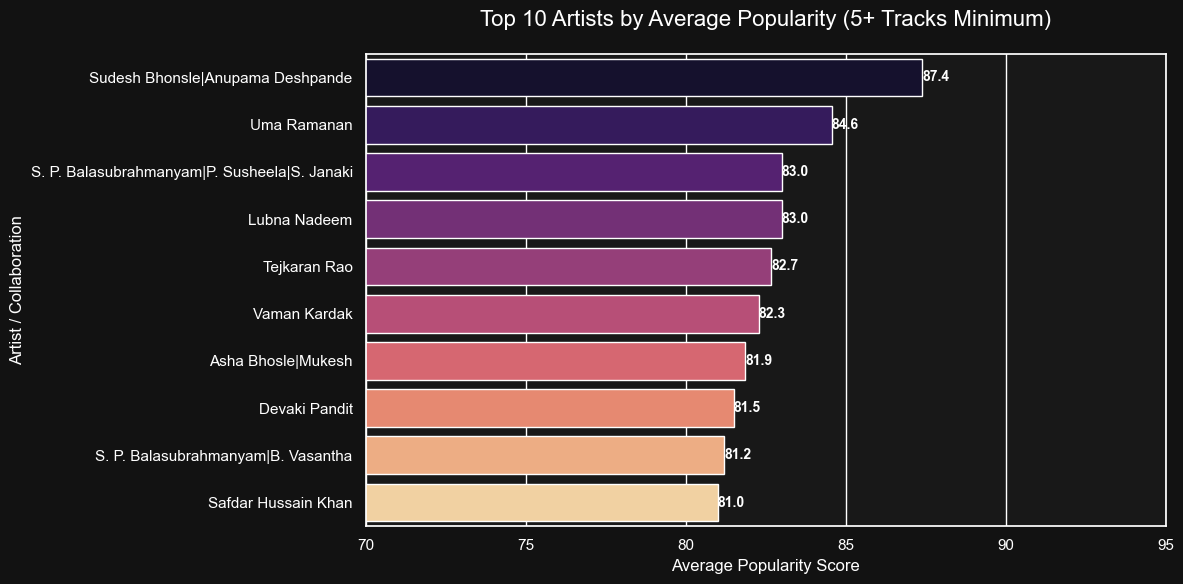

In [10]:
# Plot 2: Top 10 Artists by Average Popularity
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_by_popularity, y='singer', x='avg_popularity', palette='magma')

# Add labels
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, color='white', fontweight='bold')

plt.title('Top 10 Artists by Average Popularity (5+ Tracks Minimum)', fontsize=16, pad=20)
plt.xlabel('Average Popularity Score', fontsize=12)
plt.ylabel('Artist / Collaboration', fontsize=12)
plt.xlim(70, 95) # Zoom in on the top end to see differences
plt.tight_layout()
plt.show()